# Source span selection

**Recipe 14** · Level 2 (Easy) · Decision type: `Choice`

Select the supplier name from text spans already extracted by Python, with a not-stated outcome when the document lacks that field.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A small supplier-name extractor for fabricated purchase documents. Python runs a real, deterministic extractor (`helpers.extract_spans`: split the document into sentences, keep the ones naming an organisation) before Jev ever sees the document, and assigns each candidate an id and character offsets. Jev reads only those candidate spans, by id, and picks exactly one option: one of this document's own span ids, or the shared fallback `not_stated` for a document that does not name a supplier at all. A document with no candidate spans gets no question at all -- Python already knows the answer and reports it directly, spending no request. Python decides nothing about which organisation the text actually names as the supplier; it only decides whether a named pick is confident enough to report the exact span text -- sliced from the document at the offsets the extractor found, never retyped -- or whether it should go to an explicit review outcome instead, which never happens for `not_stated`, since there is no stored span text a confidence check could protect there. The supplier is not always the last span, or the first, or the only one using an obvious disclosure word: "Evaluation" below shows three model-free baselines that this layout defeats, so the typed answer has something real to beat. By the end you will have looked at individual typed answers across the range this recipe covers, then the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports exact-match accuracy and `not_stated` handling on `test`, with the frozen confidence gate's real effect shown next to what answering everything would have done. The fixtures hold 43 fabricated documents: 41 are scored (20 `validation`, 21 `test`) and 2 are `demo` only.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline (3 of the 43 documents have no candidate span at all, so Python decides `not_stated` for them directly and never asks a question -- see "Python's part"); setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." Offline, a validation number is also a pipeline check: synthetic data checks that
# the pipeline works, and choosing on it is still only a selection step, not a reported result,
# so both labels apply at once and a validation line carries both, in this order.
selection = " (a selection step, not a reported result)"

# Every document needs at most one request: one per document that has at least one candidate
# span (40 of the 43), cached by id so a document shown individually and later scored in its
# split is decided once. A document with no candidate span never reaches this cache at all --
# "Python's part" below short-circuits it before any question is built.
answered = {}


def decide(example):
    spans = helpers.spans_by_id(example.fields)
    if not spans:
        return None
    if example.id not in answered:
        questions = helpers.build_questions(example.fields)
        state = helpers.build_state(example.fields)
        answered[example.id] = backend.decide(state, questions)["supplier_span"]
    return answered[example.id]


run_header(14, "Source span selection", backend=backend, n_examples=len(scored))

Recipe 14: Source span selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 41 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `doc_id` and the full `document` text, nothing else -- there is no stored span list to drift from the extractor. `build_state` runs `helpers.extract_spans` on the document and passes on only the sliced text of each candidate span, by id; the document itself and the offsets stay in Python, and the identifier is attached to the outcome at the end, so neither ever passes through the model and every result still traces back to its document.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-clear"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "doc_id": "D-DEMO1",
  "document": "Purchase Confirmation #9001. Bill To: Keystone Retail Group, 400 Commerce Ave. Supplier: Hollow Creek Builders Supply, 10 Timber Lane. Items: 25 sheets of plywood. Thank you for your order."
}
Jev sees:
{
  "spans": {
    "s1": "Bill To: Keystone Retail Group, 400 Commerce Ave. ",
    "s2": "Supplier: Hollow Creek Builders Supply, 10 Timber Lane. "
  }
}


## The extractor

`helpers.extract_spans` is plain text processing, not a model: it splits a document into sentences (`split_sentences`, on a `.`, `!` or `?` followed by whitespace, skipping a split right after a short list of company-name abbreviations such as "Co." so "Riverside Packaging Co. was our vendor" stays one sentence) and keeps the ones containing an organisation cue -- one to four capitalized words immediately followed by a legal-entity-shaped suffix such as "Inc", "LLC", "Group" or "Bank". A sentence naming a buyer, a bank, a carrier, or a superseded vendor is exactly as much a candidate as one naming the real supplier: the extractor's job is only to find every organisation mention, never to judge which one is the supplier. `build_fixtures.py` calls this same function on every document's own text to compute the candidates and offsets fixtures ship with; the notebook calls it again, identically, so the two can never drift.

In [3]:
sample = demo["d01-clear"].fields["document"]
print(sample)
print()
for start, end in helpers.split_sentences(sample):
    sentence = sample[start:end]
    is_candidate = bool(helpers.extract_spans(sentence))
    print(f"{'candidate' if is_candidate else '   -     '}  {sentence!r}")

Purchase Confirmation #9001. Bill To: Keystone Retail Group, 400 Commerce Ave. Supplier: Hollow Creek Builders Supply, 10 Timber Lane. Items: 25 sheets of plywood. Thank you for your order.

   -       'Purchase Confirmation #9001. '
candidate  'Bill To: Keystone Retail Group, 400 Commerce Ave. '
candidate  'Supplier: Hollow Creek Builders Supply, 10 Timber Lane. '
   -       'Items: 25 sheets of plywood. '
   -       'Thank you for your order.'


## The questions

There is one question, and it asks one thing: which candidate span, if any, states who the supplier is? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives)). The option list is not the same for every document: Python builds it fresh from this document's own candidate spans (their ids only -- the text already crossed into `state` above, so the option itself carries no description) plus the shared fallback `not_stated`. `build_questions` is only ever called for a document that has at least one candidate span, because a `Choice` needs a non-empty option set; "Python's part" below short-circuits the other case before any question exists. Because the option set is per-document, the replay key is too: a key computed for one document's spans can never replay for another document's, even one with the same number of candidates (the same consequence recipe 07's per-word sense inventory has for its options).

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): 0 when the top option has no more than an even share of the options, 1 when one option holds all the probability. `n` is the number of candidate spans this document has, plus one for `not_stated`, and ranges from 2 (one candidate) to 5 in these fixtures. A low confidence here does not mean a span is unreadable; it means the top pick did not clear much more than an even share of this document's own options.

In [4]:
fields = demo["d01-clear"].fields
questions = helpers.build_questions(fields)
span = questions["supplier_span"]
print(span.instructions)
for name in span.criteria:
    print(f"  {name}")

Which one of the candidate spans below, if any, states who the supplier is for this purchase -- the party the goods or services were bought from? Choose 'not_stated' if none of them does.
  s1
  s2
  not_stated


## One answer up close

Before any aggregate number, look at five typed answers across the range this recipe covers: a document with one clear "Supplier:" span and a harmless decoy, a document whose supplier line uses no disclosure word at all, a document where the supplier's name appears in two different spans, a document with no candidate span at all, and a document whose stored answer is wrong and confident. All five come from `demo` or `validation`, so nothing shown here reaches into `test`. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

s1: 'Bill To: Keystone Retail Group, 400 Commerce Ave. '
s2: 'Supplier: Hollow Creek Builders Supply, 10 Timber Lane. '
Choice: s2 (confidence 0.79)
  s2          0.86  #################
  not_stated  0.09  ##
  s1          0.05  #
Provenance: synthetic


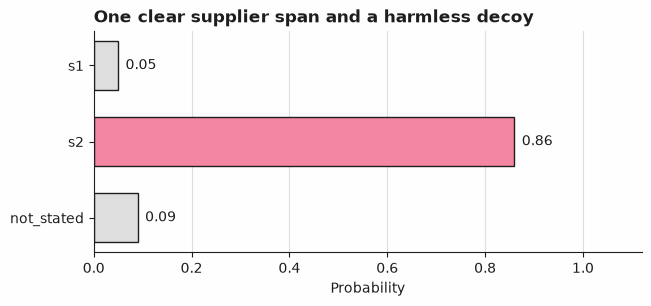

In [5]:
clear_example = demo["d01-clear"]
clear_answer = decide(clear_example)
clear_spans = helpers.spans_by_id(clear_example.fields)
for span_id, text in clear_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(clear_answer)
plot_answer_probabilities(clear_answer, title="One clear supplier span and a harmless decoy")

`s1` is Keystone Retail Group's own `Bill To:` line; `s2` names the supplier directly after a `Supplier:` label. The stored answer puts `s2` on top at 0.86, so `confidence` is 0.79: `(0.86 - 1/3) / (1 - 1/3)`, the published formula with `n = 3` (two candidate spans plus `not_stated`).

In [6]:
val_examples_preview = select_split(examples, "validation")
bare_example = next(e for e in val_examples_preview if e.id == "v03")
bare_answer = decide(bare_example)
bare_spans = helpers.spans_by_id(bare_example.fields)
for span_id, text in bare_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(bare_answer)

s1: 'Ashgrove Fixtures Co. shipped this order from 9 Lattice Row. '
s2: 'Bill To: Keystone Retail Group, 400 Commerce Ave. '
Choice: s1 (confidence 0.70)
  s1          0.80  ################
  not_stated  0.14  ###
  s2          0.06  #
Provenance: synthetic


`s1` names the supplier with no disclosure word at all -- "Ashgrove Fixtures Co. shipped this order from 9 Lattice Row", not "Supplier: ..." or "...supplied by...". There is nothing for a lexical cue to match here; the stored answer still puts `s1` on top at 0.80, confidence 0.70. "Evaluation" below shows what a baseline that only looks for a disclosure word does with documents shaped like this one.

In [7]:
twospan_example = next(e for e in val_examples_preview if e.id == "v14")
twospan_answer = decide(twospan_example)
twospan_spans = helpers.spans_by_id(twospan_example.fields)
for span_id, text in twospan_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(twospan_answer)

s1: 'This delivery was prepared by Brightwell Hardware Inc., our supplier of fasteners and tools. '
s2: 'Please remit payment to Brightwell Hardware Inc., Accounts Receivable, 55 Industrial Way. '
Choice: s2 (confidence 0.52)
  s2          0.68  ##############
  s1          0.22  ####
  not_stated  0.10  ##
Provenance: synthetic


Brightwell Hardware Inc. is named twice: `s1` introduces who prepared the delivery, `s2` is the remit-to line. The stored answer puts `s2` on top at 0.68, confidence 0.52. Either span would be an equally correct answer here -- "Python's part" below explains why the rule does not insist on one particular span id when a document states the supplier more than once.

In [8]:
nocand_example = demo["d02-no-candidates"]
nocand_spans = helpers.spans_by_id(nocand_example.fields)
print(nocand_example.fields["document"])
print(f"candidate spans found: {len(nocand_spans)}")
nocand_result = helpers.no_candidates(nocand_example.fields["doc_id"])
print(
    f"{nocand_result.doc_id}: no question asked -> {nocand_result.outcome} ({nocand_result.reason})"
)

Delivery Note #9002. Contents: 2 staplers and a box of highlighters. The packing slip included no vendor information.
candidate spans found: 0
D-DEMO2: no question asked -> not_stated (no candidate spans were extracted from this document)


This delivery note names no organisation at all: `extract_spans` finds zero candidates, so there is no option set to build a `Choice` from and nothing for Jev to be asked. Python reports `not_stated` directly, through `helpers.no_candidates`, with no request spent -- this is one of the three documents in these fixtures (of 43) where that happens.

s1: 'Goods ship from the Silverline Freight Services warehouse near Reno. '
s2: 'Vendor on file: Ember Stationery Co., Unit 12, Fairview Industrial Park. '
Choice: s1 (confidence 0.61)
  s1          0.74  ###############
  s2          0.18  ####
  not_stated  0.08  ##
Provenance: synthetic


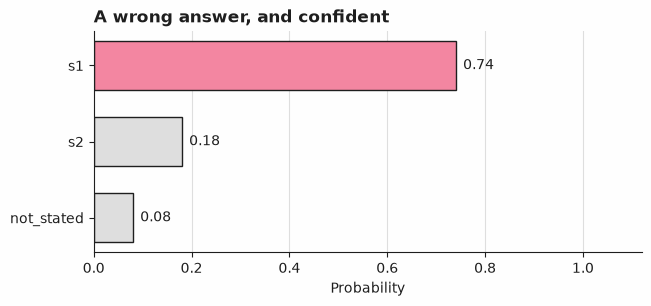

In [9]:
wrong_example = next(e for e in val_examples_preview if e.id == "v20")
wrong_answer = decide(wrong_example)
wrong_spans = helpers.spans_by_id(wrong_example.fields)
for span_id, text in wrong_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(wrong_answer)
plot_answer_probabilities(wrong_answer, title="A wrong answer, and confident")

`s1` ships the goods ("Goods ship from the Silverline Freight Services warehouse"); `s2` is the actual vendor-on-file line, Ember Stationery Co. The stored answer gets this wrong: `s1` at 0.74, confidence 0.61. This is the one wrong, confident, named answer this recipe places in `validation` on purpose -- "Python's part" below uses it to show what the frozen threshold excludes. Nothing here says *why* a real model would get a document like this wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the pick; what happens with it is code. Two documents in these fixtures (`demo`'s `d02-no-candidates`, plus one in `validation` and one in `test`) have no candidate span at all, and `helpers.no_candidates` reports `not_stated` for them directly, before any question is built and with no request spent -- Python already knows the answer when there is nothing to pick from.

For every other document, `select_span` returns a confident pick's exact span text, sliced from the document by offset, and decides three things: `not_stated` is reported as a final result whatever its confidence (CONTRIBUTING.md section 4: a low-confidence fallback option may be delivered as a final result instead of going to review when choosing it triggers no side effect -- here, choosing `not_stated` routes nothing, answers nothing and moves nothing; there is no stored span text to protect, the same reasoning recipe 08's `no_match` uses); a choice naming something other than one of this document's own candidate spans goes to `review` regardless of confidence (defensive, since `build_questions` never offers such an option, but the rule does not trust that silently); and anything else goes to `review` only when its **confidence gate** -- the threshold on `confidence` chosen below -- is not cleared. `tests/test_helpers.py` checks all three branches, the inclusive boundary, and the error outside `0` to `1`.

Here and below, "gold" means the [gold label](../../docs/glossary.md#gold-label): the correct supplier name, or the literal string `not_stated`, written into `fixtures/labels.jsonl` before this notebook ever runs, never produced by Jev. A document whose supplier's name appears in two spans (`v14` above, and others below) has no single "right" span id: "exact match on the supplier name" means the *returned span text* contains the gold name verbatim, not that one particular id is the sole correct answer -- `matches_gold` and `is_correct` check the text, so either qualifying span counts as correct.

The confidence gate itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose accepted subset is perfectly accurate, over the `validation` documents whose raw choice names a real span. Documents whose raw choice is `not_stated` are excluded from this selection on purpose -- `select_span` never applies the gate to them, so feeding their confidence into the same selection would tune a gate the rule does not have, the same exclusion recipe 08 applies to `no_match`.

In [10]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_spans = [helpers.spans_by_id(e.fields) for e in val_examples]

named = [
    (helpers.matches_gold(a.choice, s, g), a.confidence)
    for a, s, g in zip(val_answers, val_spans, val_gold, strict=True)
    if a is not None and a.choice != helpers.NOT_STATED
]
named_correct = [c for c, _ in named]
named_confidence = [c for _, c in named]
threshold = select_confidence_threshold(named_correct, named_confidence, target_accuracy=1.0)
print(
    f"chosen threshold, frozen from here on: {threshold:.4f} "
    f"(over {len(named)} named picks in validation, {named_correct.count(False)} of them "
    f"wrong){selection}{check}"
)

for shown_example, shown_answer in (
    (clear_example, clear_answer),
    (bare_example, bare_answer),
    (twospan_example, twospan_answer),
    (wrong_example, wrong_answer),
):
    spans = helpers.spans_by_id(shown_example.fields)
    result = helpers.select_span(shown_example.fields["doc_id"], shown_answer, spans, threshold)
    print(
        f"{result.doc_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )
print(
    f"{nocand_result.doc_id}: no question asked -> {nocand_result.outcome} ({nocand_result.reason})"
)

chosen threshold, frozen from here on: 0.6533 (over 16 named picks in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
D-DEMO1: s2 at confidence 0.79 -> supported (confident match)
D03: s1 at confidence 0.70 -> supported (confident match)
D25: s2 at confidence 0.52 -> review (confidence below the threshold)
D37: s1 at confidence 0.61 -> review (confidence below the threshold)
D-DEMO2: no question asked -> not_stated (no candidate spans were extracted from this document)


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section first checks the fixtures themselves -- where the gold span actually sits, and whether a baseline with no model at all could already answer this -- and then reports what the frozen rule does, calling `helpers.select_span` and `helpers.no_candidates` on every example, never reimplementing either. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries that label as well.

### Where the gold span sits

If the supplier were always the last candidate span (or always the first, or always the only one using a disclosure word like "Supplier:"), a reader could reasonably ask whether this `Choice` is teaching anything beyond position or a lexical trick. The table below counts, for every scored document, which position (1st, 2nd, 3rd, ...) among its own candidate spans actually names the supplier, from `fixtures/labels.jsonl` and `helpers.gold_positions` -- not from any stored answer.

In [11]:
from collections import Counter

position_counts = Counter()
for e in scored:
    gold = labels[e.id]
    spans = helpers.spans_by_id(e.fields)
    positions = helpers.gold_positions(spans, gold)
    position_counts[tuple(positions) if positions else ("not_stated",)] += 1

for key in sorted(position_counts, key=lambda k: (k == ("not_stated",), k)):
    label = "not_stated (no supplier named)" if key == ("not_stated",) else f"position {key}"
    print(f"  {label}: {position_counts[key]}{check}")

  position (1,): 13 (a pipeline check, not a Jev result)
  position (1, 2): 2 (a pipeline check, not a Jev result)
  position (1, 3): 1 (a pipeline check, not a Jev result)
  position (2,): 11 (a pipeline check, not a Jev result)
  position (2, 3): 1 (a pipeline check, not a Jev result)
  position (3,): 3 (a pipeline check, not a Jev result)
  position (4,): 2 (a pipeline check, not a Jev result)
  not_stated (no supplier named): 8 (a pipeline check, not a Jev result)


### Three baselines with no model at all

Three deterministic, model-free baselines (`helpers.last_span_baseline`, `first_span_baseline`, `cue_regex_baseline`) each pick a span -- or `not_stated` -- using only position or a short, literal word list (`CUE_WORDS`), never Jev's answer. `docs/fixtures.md`: "Avoid synthetic responses so tidy that every model-free baseline scores perfectly on `test`." The table below scores each baseline, and the stored answers, against the gold label with `matches_gold`, the same check `select_span`'s correctness rests on.

In [12]:
def raw_choice(example, spans, answer):
    if answer is None:
        return helpers.NOT_STATED
    return answer.choice


def baseline_accuracy(baseline, examples_, spans_list, gold_):
    picks = [baseline(s) for s in spans_list]
    correct = [
        helpers.matches_gold(p, s, g) for p, s, g in zip(picks, spans_list, gold_, strict=True)
    ]
    return sum(correct) / len(correct)


for split_name, split_examples in (("validation", val_examples), ("test", None)):
    if split_examples is None:
        split_examples = select_split(examples, "test")
    split_answers = [decide(e) for e in split_examples]
    split_spans = [helpers.spans_by_id(e.fields) for e in split_examples]
    split_gold = [labels[e.id] for e in split_examples]
    stored_picks = [
        raw_choice(e, s, a)
        for e, s, a in zip(split_examples, split_spans, split_answers, strict=True)
    ]
    stored_correct = [
        helpers.matches_gold(p, s, g)
        for p, s, g in zip(stored_picks, split_spans, split_gold, strict=True)
    ]
    label = selection if split_name == "validation" else ""
    print(f"{split_name} ({len(split_examples)} examples){label}{check}")
    print(f"  stored answers:        {sum(stored_correct) / len(stored_correct):.4f}{label}{check}")
    for name, fn in (
        ("always take the last span", helpers.last_span_baseline),
        ("always take the first span", helpers.first_span_baseline),
        ("last span with a disclosure cue", helpers.cue_regex_baseline),
    ):
        acc = baseline_accuracy(fn, split_examples, split_spans, split_gold)
        print(f"  {name + ':':30s} {acc:.4f}{label}{check}")

validation (20 examples) (a selection step, not a reported result) (a pipeline check, not a Jev result)
  stored answers:        0.9500 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  always take the last span:     0.4000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  always take the first span:    0.5000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  last span with a disclosure cue: 0.7500 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test (21 examples) (a pipeline check, not a Jev result)
  stored answers:        0.8095 (a pipeline check, not a Jev result)
  always take the last span:     0.4762 (a pipeline check, not a Jev result)
  always take the first span:    0.3810 (a pipeline check, not a Jev result)
  last span with a disclosure cue: 0.5238 (a pipeline check, not a Jev result)


On both splits the stored answers clear every baseline by a wide margin: 0.9500 against at most 0.7500 on `validation`, and 0.8095 against at most 0.5238 on `test`. "Always take the last span" and "always take the first span" each fail on roughly half of both splits, by construction: the position table above shows the gold span spread across 1st, 2nd, 3rd and 4th place, and across two spans at once for four documents, so neither fixed position is a safe bet. The disclosure-cue baseline does better than pure position but still falls well short, for two reasons visible in "One answer up close": `v03`'s supplier line uses no disclosure word at all (the baseline would report `not_stated`, wrongly), and a decoy can borrow the same cue word a real disclosure uses (`CUE_WORDS` includes "remit", which also appears in "Remit any shipping inquiries to ...", a shipping decoy, not the supplier) and out-rank the real line if it comes later in the document.

In [13]:
def report(chosen, decided, gold, spans):
    """Apply select_span (or no_candidates) to every answer and tally what it actually
    did, calling the rule itself -- never a reimplementation of its conditions."""
    results = []
    for e, a, s in zip(chosen, decided, spans, strict=True):
        if a is None:
            results.append(helpers.no_candidates(e.fields["doc_id"]))
        else:
            results.append(helpers.select_span(e.fields["doc_id"], a, s, threshold))
    correct = [helpers.is_correct(r, g) for r, g in zip(results, gold, strict=True)]
    counts = {helpers.SUPPORTED: 0, helpers.REVIEW: 0, helpers.NOT_STATED_OUTCOME: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, correct, counts


val_results, val_correct, val_counts = report(val_examples, val_answers, val_gold, val_spans)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"supported: {val_counts[helpers.SUPPORTED]}, review: {val_counts[helpers.REVIEW]}, "
    f"not_stated: {val_counts[helpers.NOT_STATED_OUTCOME]} (of {len(val_examples)})"
    f"{selection}{check}"
)
print(f"reviewed in validation, listed individually{selection}{check}:")
for e, r, g in zip(val_examples, val_results, val_gold, strict=True):
    if r.outcome == helpers.REVIEW:
        was_right = helpers.matches_gold(r.choice, helpers.spans_by_id(e.fields), g)
        print(
            f"  {e.id} ({r.doc_id}): chose {r.choice}, sent to review ({r.reason}); "
            f"the raw choice was {'right' if was_right else 'wrong'}"
        )

validation, 20 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
supported: 13, review: 3, not_stated: 4 (of 20) (a selection step, not a reported result) (a pipeline check, not a Jev result)
reviewed in validation, listed individually (a selection step, not a reported result) (a pipeline check, not a Jev result):
  v14 (D25): chose s2, sent to review (confidence below the threshold); the raw choice was right
  v15 (D26): chose s1, sent to review (confidence below the threshold); the raw choice was right
  v20 (D37): chose s1, sent to review (confidence below the threshold); the raw choice was wrong


Three `validation` documents are reviewed: `v14` and `v15` each name the right span (the supplier named twice) but too unconfidently to clear the frozen 0.6533, and `v20` is the one answer this recipe places in `validation` on purpose, wrong and confident (`s1`, the shipping-carrier decoy, at confidence 0.6100) -- exactly the error the threshold is chosen to exclude. Without `v20`, every real-span answer in `validation` would already be correct, and `select_confidence_threshold(..., target_accuracy=1.0)` would have nothing to cut on; with it, the threshold has a real wrong answer to exclude, and it does.

In [14]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_spans = [helpers.spans_by_id(e.fields) for e in test_examples]

test_results, test_correct, test_counts = report(test_examples, test_answers, test_gold, test_spans)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(
    f"supported: {test_counts[helpers.SUPPORTED]}, review: {test_counts[helpers.REVIEW]}, "
    f"not_stated: {test_counts[helpers.NOT_STATED_OUTCOME]} (of {len(test_examples)}){check}"
)
print(f"reviewed in test, listed individually{check}:")
for e, r, g in zip(test_examples, test_results, test_gold, strict=True):
    if r.outcome == helpers.REVIEW:
        was_right = helpers.matches_gold(r.choice, helpers.spans_by_id(e.fields), g)
        print(
            f"  {e.id} ({r.doc_id}): chose {r.choice}, sent to review ({r.reason}); "
            f"the raw choice was {'right' if was_right else 'wrong'}{check}"
        )
print(f"wrong, but answered anyway{check}:")
for e, r, g in zip(test_examples, test_results, test_gold, strict=True):
    if r.outcome != helpers.REVIEW and not helpers.is_correct(r, g):
        print(f"  {e.id} ({r.doc_id}): {r.outcome} ({r.choice!r}), gold {g!r}{check}")

test, 21 examples, threshold 0.6533 frozen (a pipeline check, not a Jev result)
supported: 8, review: 8, not_stated: 5 (of 21) (a pipeline check, not a Jev result)
reviewed in test, listed individually (a pipeline check, not a Jev result):
  t07 (D17): chose s2, sent to review (confidence below the threshold); the raw choice was right (a pipeline check, not a Jev result)
  t08 (D18): chose s2, sent to review (confidence below the threshold); the raw choice was right (a pipeline check, not a Jev result)
  t09 (D20): chose s3, sent to review (confidence below the threshold); the raw choice was right (a pipeline check, not a Jev result)
  t10 (D22): chose s1, sent to review (confidence below the threshold); the raw choice was right (a pipeline check, not a Jev result)
  t12 (D27): chose s3, sent to review (confidence below the threshold); the raw choice was right (a pipeline check, not a Jev result)
  t13 (D28): chose s1, sent to review (confidence below the threshold); the raw choice was

`test`'s review list holds eight documents, six of them raw-correct but too unconfident to clear 0.6533 (`t07`, `t08`, `t09`, `t10`, `t12`, `t13`) and two raw-wrong and caught (`t19`, `t20`) -- `t20`'s stored answer barely prefers the wrong decoy, at confidence 0.1300, well below the gate. Two documents are wrong and answered anyway, in different ways. `t18` (gold `Amberline Textiles Co.`) is wrong and confident: the near-miss decoy, the superseded supplier, is chosen at confidence 0.7000, comfortably above the frozen threshold, so the rule accepts it anyway -- a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any document this recipe has not seen. `t21` (gold `Pinehollow Office Supply`) is wrong the other way: the stored answer says `not_stated` at confidence 0.5200 -- *below* the frozen threshold, but that does not matter, because `select_span` never applies the gate to `not_stated` at all. The mistake here is not a gate failing to catch a wrong answer; it is a wrong answer in a branch that has no gate to fail.

### What the confidence gate actually buys on `test`

`coverage` is the fraction of documents the rule actually answered -- `supported` or `not_stated`, either one a real result handed back -- rather than held for `review`; among those answered, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction of answered documents that are wrong despite the rule having delivered a result for them. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` computes all three from `select_span`'s own accept/review decisions (never `evaluate_selective`, which assumes a confidence-only gate is the rule's only review branch -- `select_span`'s `not_stated` branch is never gated at all). Next to it, "ungated" is what reporting every raw choice, with no gate and no review at all, would have scored -- the same `matches_gold` check, over every document.

In [15]:
val_accepted = [r.outcome != helpers.REVIEW for r in val_results]
val_selective = evaluate_outcomes(val_accepted, val_correct)
test_accepted = [r.outcome != helpers.REVIEW for r in test_results]
test_selective = evaluate_outcomes(test_accepted, test_correct)

raw_test_correct = [
    helpers.matches_gold(raw_choice(e, s, a), s, g)
    for e, a, s, g in zip(test_examples, test_answers, test_spans, test_gold, strict=True)
]
ungated_accuracy = sum(raw_test_correct) / len(raw_test_correct)

print(
    f"validation (frozen gate): coverage {val_selective.coverage:.4f}, "
    f"accuracy {val_selective.accuracy:.4f}, risk {val_selective.risk:.4f}{selection}{check}"
)
print()
print(
    f"test (frozen gate):   coverage {test_selective.coverage:.4f}, "
    f"accuracy {test_selective.accuracy:.4f}, risk {test_selective.risk:.4f}{check}"
)
print(
    f"test (ungated, every document answered): coverage 1.0000, "
    f"accuracy {ungated_accuracy:.4f}, risk {1 - ungated_accuracy:.4f}{check}"
)

validation (frozen gate): coverage 0.8500, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test (frozen gate):   coverage 0.6190, accuracy 0.8462, risk 0.1538 (a pipeline check, not a Jev result)
test (ungated, every document answered): coverage 1.0000, accuracy 0.8095, risk 0.1905 (a pipeline check, not a Jev result)


On `test` the gate genuinely helps: ungated accuracy is 0.8095 (17 of 21 right, the same four wrong raw choices named above: `t18`, `t19`, `t20`, `t21`); the frozen gate raises that to 0.8462 among the documents it still answers, at the cost of coverage falling to 0.6190. It does this by catching two of the four raw errors -- `t19` and `t20`, both low-confidence -- while leaving `t18` (confident and wrong) and `t21` (routed through the un-gated `not_stated` branch) untouched. That is a real trade, not a free improvement: eight of the documents the gate sends to review were already right (the review list above), so coverage is given up to catch two mistakes, and two others survive regardless. Neither number is a guarantee about anything but this fixture set.

### A confidence-only view of the same test answers

`select_span`'s `not_stated` branch is exempt from the confidence gate by design (CONTRIBUTING.md section 4). What would a gate that did *not* exempt it -- `evaluate_selective`, gating every raw choice, `not_stated` included, on the same frozen threshold -- have scored on the same answers?

In [16]:
confidence_only = [
    1.0 if a is None else a.confidence  # a document with no candidates is a sure thing
    for a in test_answers
]
confidence_only_view = evaluate_selective(raw_test_correct, confidence_only, threshold)
print(
    f"test, gate applied to every raw choice (including not_stated): "
    f"coverage {confidence_only_view.coverage:.4f}, "
    f"accuracy {confidence_only_view.accuracy:.4f}, "
    f"risk {confidence_only_view.risk:.4f}{check}"
)
print(
    f"test, select_span's actual rule: "
    f"coverage {test_selective.coverage:.4f}, "
    f"accuracy {test_selective.accuracy:.4f}, "
    f"risk {test_selective.risk:.4f}{check}"
)

test, gate applied to every raw choice (including not_stated): coverage 0.4286, accuracy 0.8889, risk 0.1111 (a pipeline check, not a Jev result)
test, select_span's actual rule: coverage 0.6190, accuracy 0.8462, risk 0.1538 (a pipeline check, not a Jev result)


A confidence-only gate would have caught `t21`: its `not_stated` pick has confidence 0.5200, below the frozen 0.6533, so a gate that applied to every raw choice would have sent it to review instead of reporting it wrong, lowering risk from 0.1538 to 0.1111 -- at a further coverage cost (0.6190 to 0.4286). It would *not* have caught `t18`: that pick is genuinely confident (0.7000) as well as wrong, so no confidence threshold on this data separates it from a correct answer. CONTRIBUTING.md section 4's exemption for `not_stated` is a defensible choice -- choosing it truly has no side effect to protect -- but it is not free here: it is the reason `t21` survives ungated while a plain confidence gate would have caught it.

  gate >= 0.8200: coverage 0.0625, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.8050: coverage 0.1250, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7750: coverage 0.1875, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7333: coverage 0.2500, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7300: coverage 0.3125, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7067: coverage 0.3750, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  gate >= 0.7000: coverage 0.5000, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

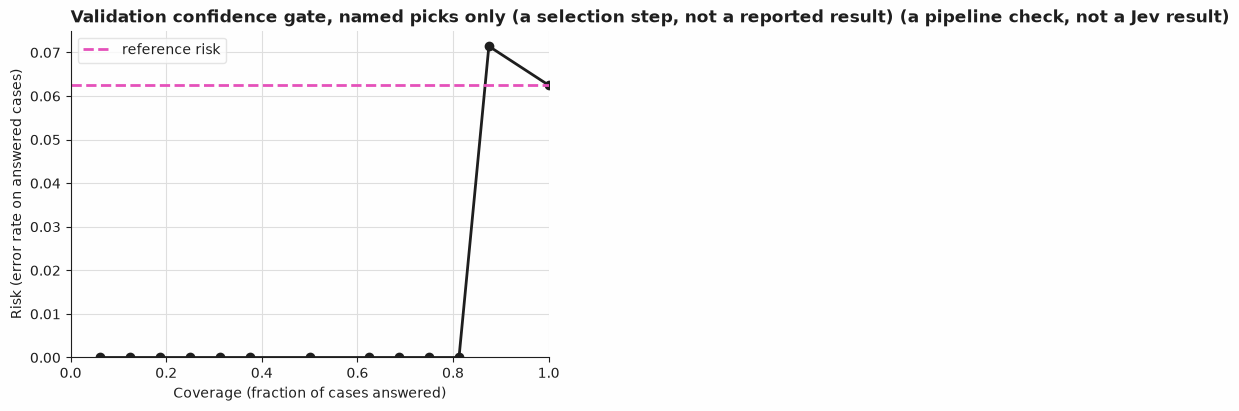

In [17]:
curve = selective_curve(named_correct, named_confidence)
for t, cov, acc, risk in zip(
    curve.thresholds, curve.coverage, curve.accuracy, curve.risk, strict=True
):
    marker = " <- frozen" if abs(t - threshold) < 1e-9 else ""
    print(
        f"  gate >= {t:.4f}: coverage {cov:.4f}, accuracy {acc:.4f}, risk {risk:.4f}{marker}{selection}{check}"
    )
plot_risk_coverage(
    curve,
    reference_risk=1 - sum(named_correct) / len(named_correct),
    title=f"Validation confidence gate, named picks only{selection}{check}",
)

Accuracy stays 1.0000 at every threshold from 0.6533 up to 0.8200 -- the gap between 0.6100 (`v20`'s confidence, the wrong answer) and 0.6533 is empty of any other observed value, so `select_confidence_threshold`'s choice of the *lowest* threshold meeting the target lands exactly at 0.6533, the smallest value that still excludes `v20`. Below 0.6533, accuracy falls to 0.9286 at 0.6100 (admitting `v20`) and recovers slightly to 0.9375 at 0.5200 (admitting everything named): on this fixture set the chosen threshold is pinned to a real gap in the data, not to an arbitrary point on a smooth curve.

['not_stated', 'named']
[[4, 0], [1, 16]]


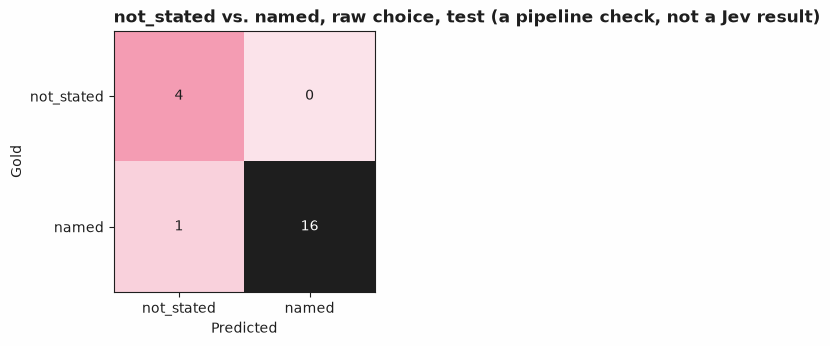

In [18]:
def label_of(answer):
    if answer is None or answer.choice == helpers.NOT_STATED:
        return helpers.NOT_STATED
    return "named"


test_gold_labels = [helpers.NOT_STATED if g == helpers.NOT_STATED else "named" for g in test_gold]
test_pred_labels = [label_of(a) for a in test_answers]
matrix = confusion_matrix(test_gold_labels, test_pred_labels, labels=[helpers.NOT_STATED, "named"])
print(matrix.labels)
print(matrix.matrix.tolist())
plot_confusion_matrix(matrix, title=f"not_stated vs. named, raw choice, test{check}")

Rows are the gold label, columns the raw choice, each counted on the same two classes: `not_stated` (the document names no supplier) against "named" (it does). `precision` is the fraction of the rule's raw `not_stated` calls that were actually right, and `recall` is the fraction of the truly-`not_stated` documents the rule actually caught; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` documents actually carry that gold label.

In [19]:
per_class = per_class_metrics(
    test_gold_labels, test_pred_labels, labels=[helpers.NOT_STATED, "named"]
)
for label, counts in per_class.items():
    print(
        f"{label:10s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

not_stated precision 0.800  recall 1.000  f1 0.889  support 4 (a pipeline check, not a Jev result)
named      precision 1.000  recall 0.941  f1 0.970  support 17 (a pipeline check, not a Jev result)


`not_stated`'s precision (0.800) is 4 of the 5 documents the rule called `not_stated` that truly had no supplier: the fifth is `t21` above, a real `Pinehollow Office Supply` document the rule misreads as having no supplier at all. Its recall (1.000) is a perfect 4 of 4 -- every truly-`not_stated` `test` document is caught. "named"'s recall (0.941) pays for that same `t21` mistake from the other side: 16 of the 17 documents that do name a supplier are read that way; its precision (1.000) is perfect, because no document that truly has no supplier is ever misread as naming one.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the extractor, the rule and the evaluation behave as designed on 41 scored documents (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, several of them wrong on purpose and spread across different positions and branches -- one in `validation` (`v20`, picking the first of two spans); three in `test` (`t18`, picking a near-miss decoy; `t19`, picking a middle decoy out of three; `t20`, wrong but caught by the gate; `t21`, a wrong `not_stated` the gate is never applied to) -- so every number above describes this fixture set and not a model.

In [20]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard document to `ROWS` in `build_fixtures.py` -- vary where the supplier line sits among the candidates, and try one with no disclosure word at all -- then run `python build_fixtures.py` and see where `select_span` sends it.
- Loosen the confidence gate's target in the evaluation cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how coverage and the review count trade off.
- Neighbouring recipes: [`07-word-sense-selection`](../07-word-sense-selection/) (a per-item option set built fresh per example, like this recipe's per-document spans) and [`08-faq-selection`](../08-faq-selection/) (a `Choice` with its own unconditional fallback outcome, `no_match`, the same shape `not_stated` has here).